# Librerias

In [45]:
import pandas as pd
import tensorflow as tf
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow_decision_forests as tfdf
import numpy as np
import keras
import seaborn as sns
from keras import layers
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency, chi2 as chi2_dist
from sklearn.metrics import mean_absolute_error
#from ydata_profiling import ProfileReport


print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Built with CUDA:", tf.test.is_built_with_cuda())

Num GPUs Available:  0
Built with CUDA: True


In [19]:
df = pd.read_csv('Datos/santiago_actualizado_final_REAL.csv')
df = df.dropna()
df = df.drop(['id'], axis = 1)

# Analisis exploratorio de los datos

## Histogramas

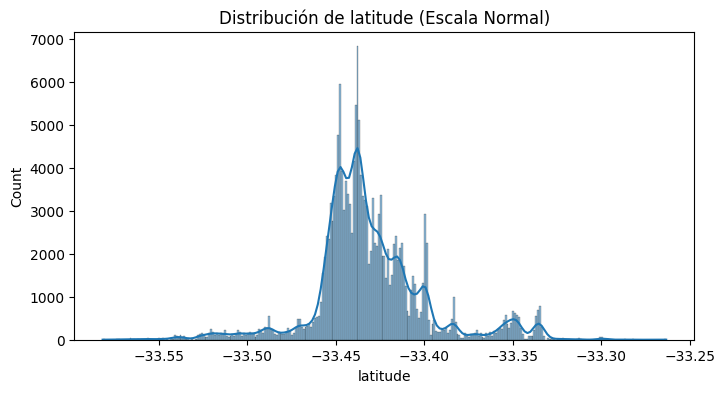

latitude - skewness> 0.49
latitude - Kurtosis> 2.66
------------------------------


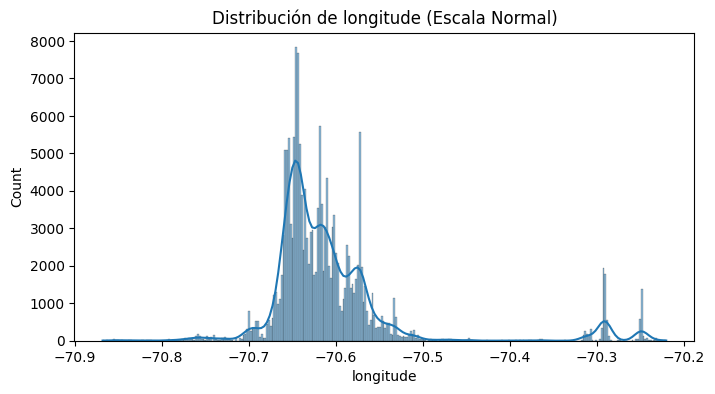

longitude - skewness> 2.73
longitude - Kurtosis> 8.56
------------------------------


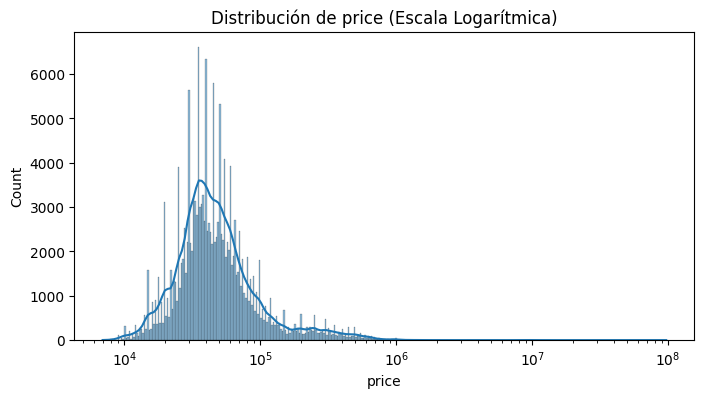

price - skewness> 84.17
price - Kurtosis> 7897.91
------------------------------


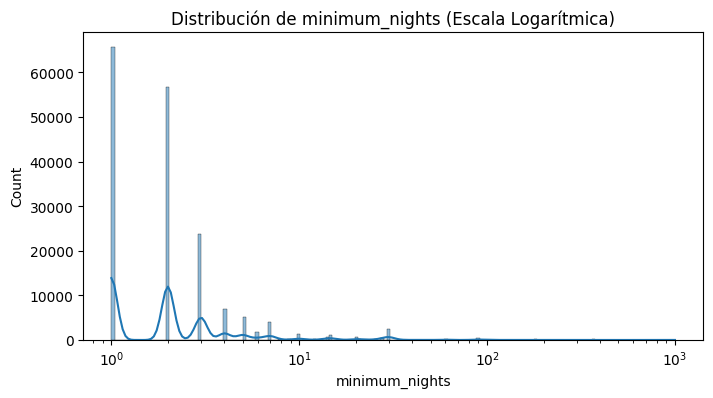

minimum_nights - skewness> 26.76
minimum_nights - Kurtosis> 931.14
------------------------------


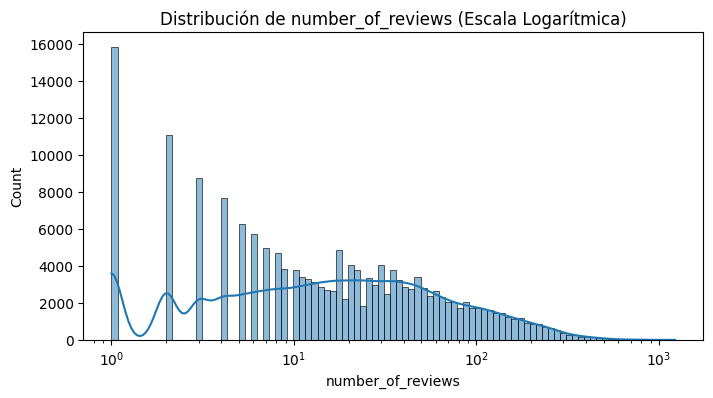

number_of_reviews - skewness> 4.36
number_of_reviews - Kurtosis> 35.11
------------------------------


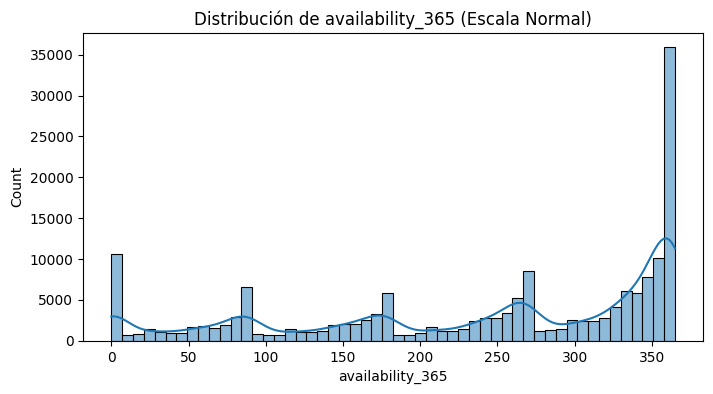

availability_365 - skewness> -0.68
availability_365 - Kurtosis> -0.88
------------------------------


/home/branco/anaconda3/envs/IA/lib/python3.10/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


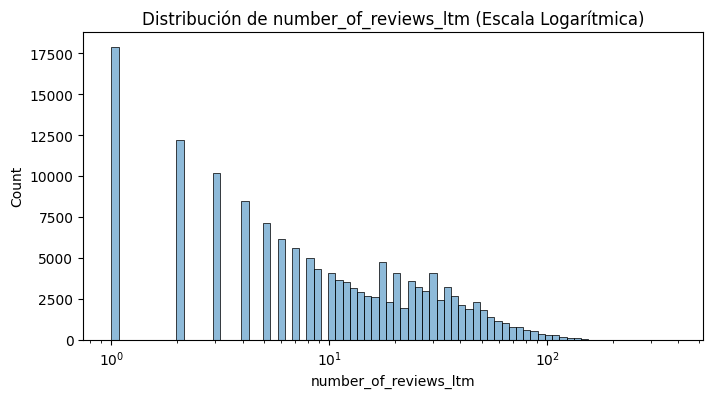

number_of_reviews_ltm - skewness> 2.70
number_of_reviews_ltm - Kurtosis> 12.65
------------------------------


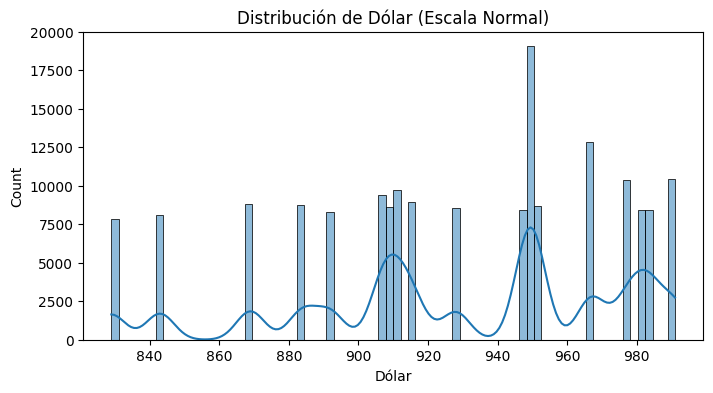

Dólar - skewness> -0.52
Dólar - Kurtosis> -0.62
------------------------------


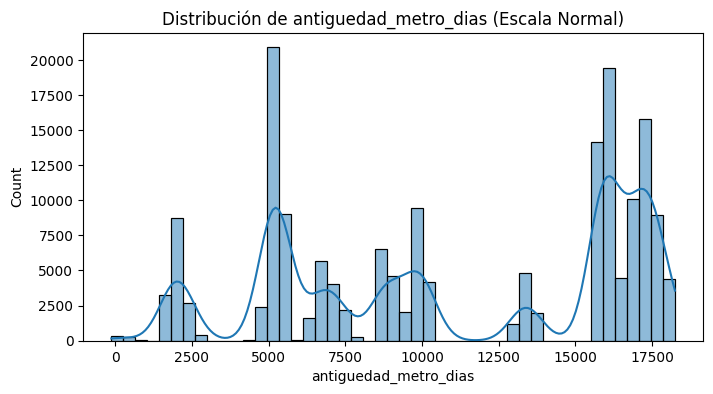

antiguedad_metro_dias - skewness> -0.24
antiguedad_metro_dias - Kurtosis> -1.49
------------------------------


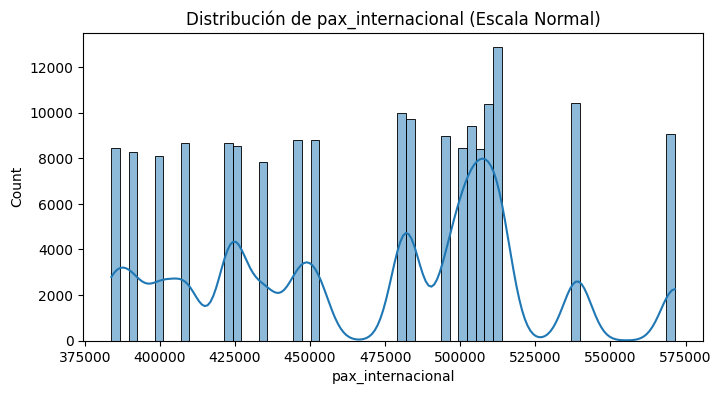

pax_internacional - skewness> -0.05
pax_internacional - Kurtosis> -0.97
------------------------------


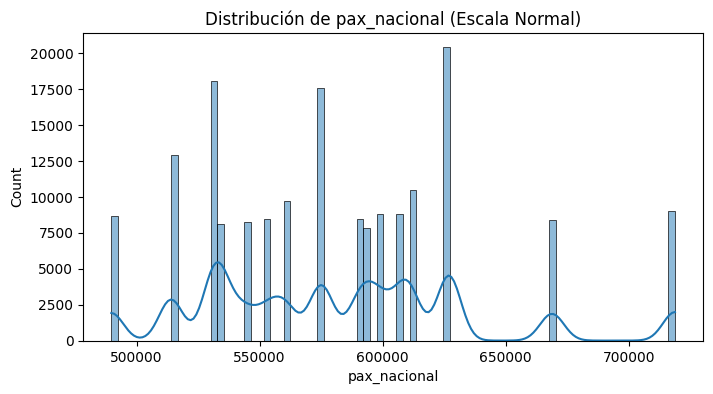

pax_nacional - skewness> 0.62
pax_nacional - Kurtosis> 0.20
------------------------------


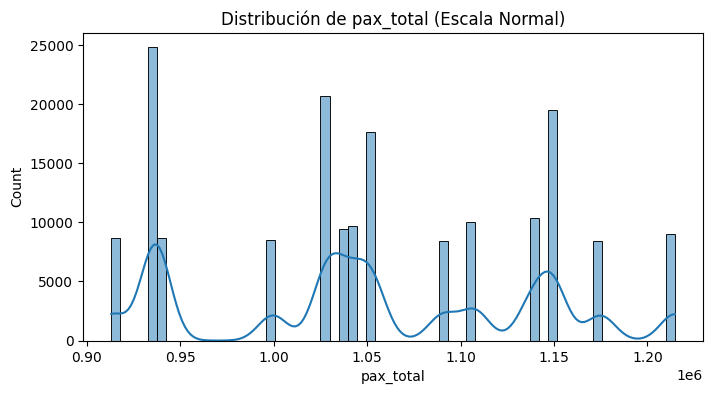

pax_total - skewness> 0.05
pax_total - Kurtosis> -1.01
------------------------------


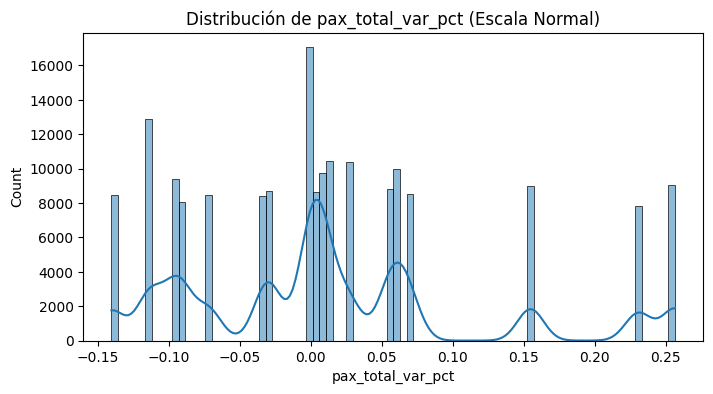

pax_total_var_pct - skewness> 0.81
pax_total_var_pct - Kurtosis> 0.23
------------------------------


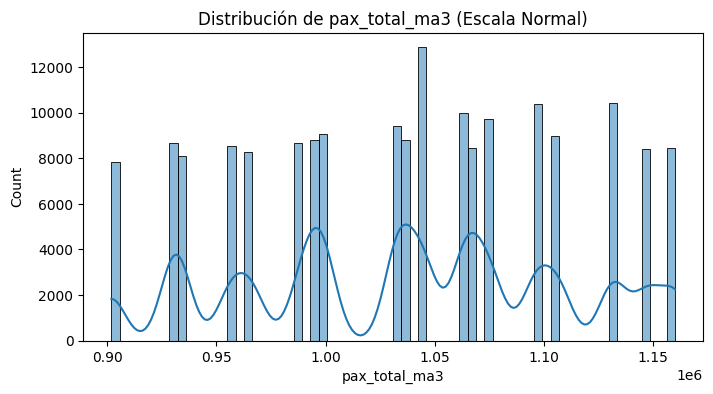

pax_total_ma3 - skewness> -0.08
pax_total_ma3 - Kurtosis> -0.95
------------------------------


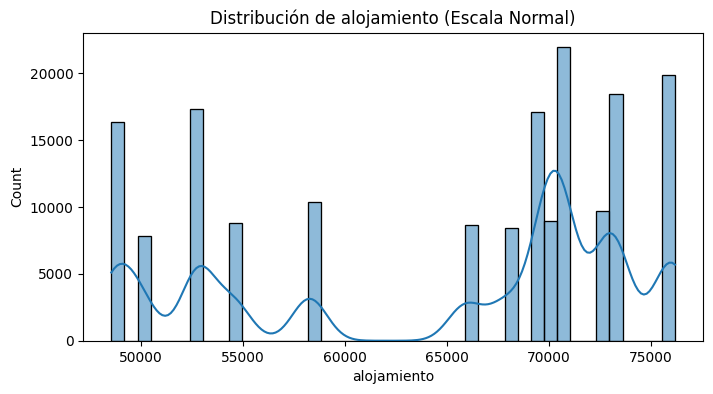

alojamiento - skewness> -0.57
alojamiento - Kurtosis> -1.28
------------------------------


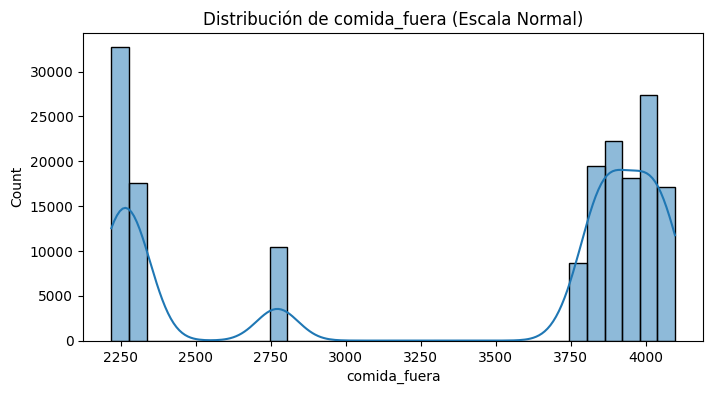

comida_fuera - skewness> -0.66
comida_fuera - Kurtosis> -1.46
------------------------------


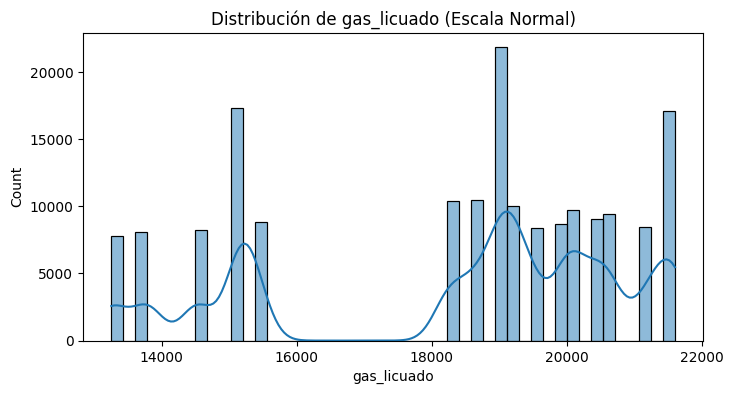

gas_licuado - skewness> -0.64
gas_licuado - Kurtosis> -0.96
------------------------------


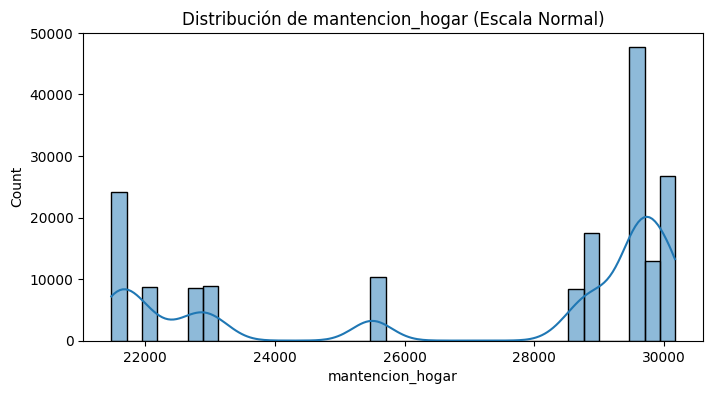

mantencion_hogar - skewness> -0.74
mantencion_hogar - Kurtosis> -1.28
------------------------------


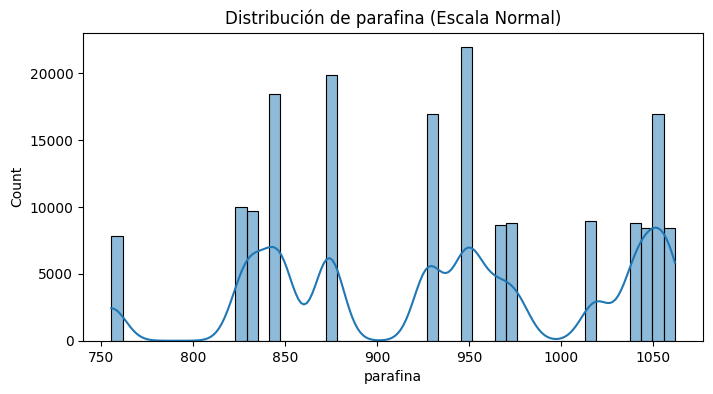

parafina - skewness> -0.14
parafina - Kurtosis> -1.06
------------------------------


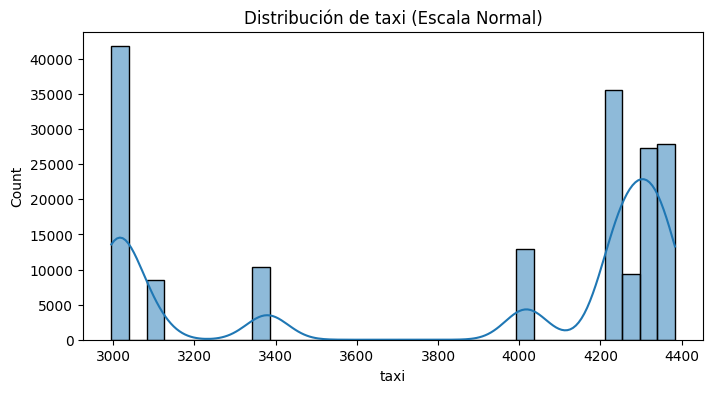

taxi - skewness> -0.63
taxi - Kurtosis> -1.48
------------------------------


In [3]:
variables_con_log = ['price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_ltm']# Agrega aquí las que se vean mal

for columna in df.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(8, 4))

    if columna in variables_con_log:
        sns.histplot(df[columna], kde=True, log_scale=True)
        plt.title(f'Distribución de {columna} (Escala Logarítmica)')
    else:
        sns.histplot(df[columna], kde=True)
        plt.title(f'Distribución de {columna} (Escala Normal)')

    plt.show() 
    print(f'{columna} - skewness> {df[columna].skew():.2f}')
    print(f'{columna} - Kurtosis> {df[columna].kurt():.2f}')
    print('-'*30)


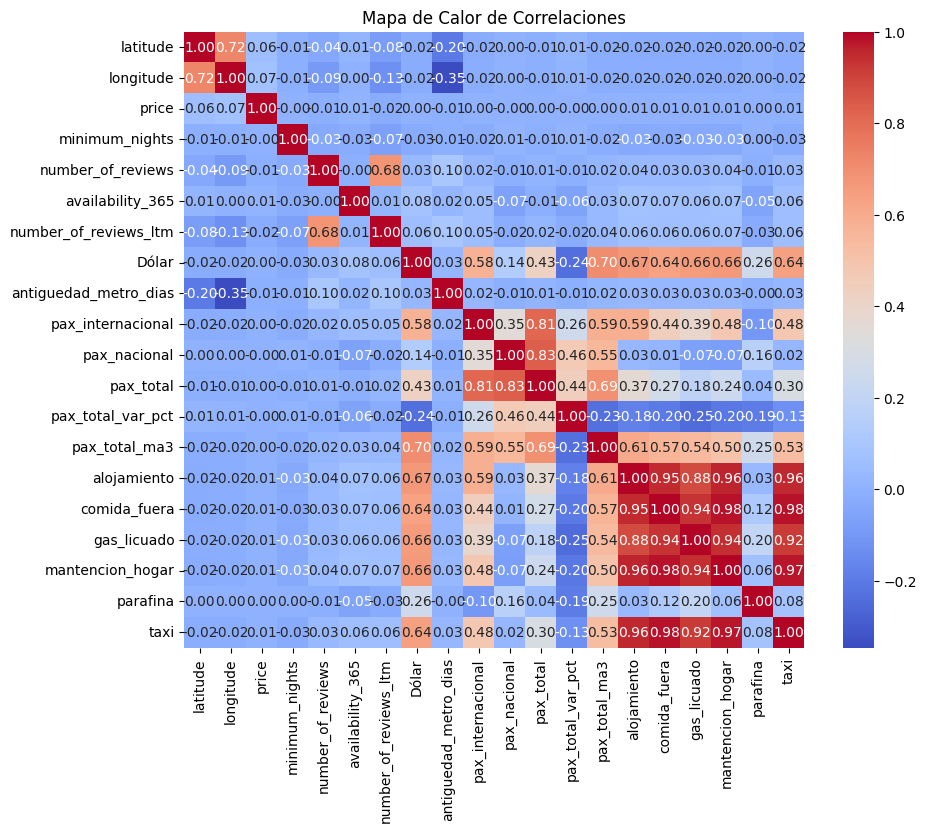

In [4]:
plt.figure(figsize=(10,8))
correlation_matrix = df.select_dtypes(include=(np.number)).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Mapa de Calor de Correlaciones")
plt.show()

In [5]:
categorical_columns = df.select_dtypes(include=['object']).columns
results = []
alpha = 0.5

for i in range(len(categorical_columns)):
    for j in range(i + 1, len(categorical_columns)):
        col1 = categorical_columns[i]
        col2 = categorical_columns[j]
        contingency_table = pd.crosstab(df[col1], df[col2])
        chi2_stat, p, dof, expected = chi2_contingency(contingency_table)
        chi2_crit = chi2_dist.ppf(1 - alpha, dof)
        results.append((col1, col2, chi2_stat, chi2_crit, p))
        
chi_results_df = pd.DataFrame(
    results,
    columns=['Variable 1', 'Variable 2', 'Xi-cuadrado', 'Valor crítico', 'p-value']
)
print("Resultados de Ji-cuadrado (p-value < 0.05 indica relación significativa):")
display(chi_results_df)

Resultados de Ji-cuadrado (p-value < 0.05 indica relación significativa):


,Variable 1,Variable 2,Xi-cuadrado,Valor crítico,p-value
0,neighbourhood,room_type,1.180916e+04,86.334249,0.000000e+00
1,neighbourhood,archivo_fecha_origen,7.651583e+02,521.333485,1.817595e-11
2,neighbourhood,nombre_estacion,3.047155e+06,3305.333357,0.000000e+00
3,neighbourhood,fecha_inauguracion_metro,1.439630e+06,666.333452,0.000000e+00
4,room_type,archivo_fecha_origen,9.251405e+02,53.334816,6.642893e-159
5,room_type,nombre_estacion,2.459931e+04,341.333565,0.000000e+00
6,room_type,fecha_inauguracion_metro,9.819314e+03,68.334491,0.000000e+00
7,archivo_fecha_origen,nombre_estacion,2.144761e+03,2051.333372,7.534668e-02
8,archivo_fecha_origen,fecha_inauguracion_metro,7.054594e+02,413.333525,1.633891e-17
9,nombre_estacion,fecha_inauguracion_metro,3.998642e+06,2621.333363,0.000000e+00


# Modelos

In [20]:
columnas_criticas =['price', 'minimum_nights', 'number_of_reviews', 'number_of_reviews_ltm']

for col in columnas_criticas:
    df[col] = np.log1p(df[col])

print("\n--- VALORES NUEVOS (Después del logaritmo) ---")
for col in columnas_criticas:
    print(f"{col.upper()}: Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurt():.2f}")


--- VALORES NUEVOS (Después del logaritmo) ---
PRICE: Skewness: 1.31, Kurtosis: 4.33
MINIMUM_NIGHTS: Skewness: 2.82, Kurtosis: 11.70
NUMBER_OF_REVIEWS: Skewness: 0.18, Kurtosis: -0.80
NUMBER_OF_REVIEWS_LTM: Skewness: -0.03, Kurtosis: -0.99


In [21]:
train_df = df.sample(frac=0.8, random_state=42) # se utiliza la funcion de pandas para retornar solo el 80% de los datos
test_df = df.drop(train_df.index) # Se elimina el 80% de los datos para retornar el 20%


train_df = tfdf.keras.pd_dataframe_to_tf_dataset( # Transforma el dataset en un diccionario de tensores para que el modelo lo pueda entender mejor
    train_df,
    task = tfdf.keras.Task.REGRESSION,
    label = 'price',
)

test_df = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_df,
    task = tfdf.keras.Task.REGRESSION,
    label = 'price',
)

train_df = train_df.prefetch(tf.data.AUTOTUNE)

## Gradient Boost 
https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/GradientBoostedTreesModel

In [55]:
model = tfdf.keras.GradientBoostedTreesModel(
    task = tfdf.keras.Task.REGRESSION, # Indica el objetivo del modelo
    num_trees = 3000,
    max_depth = 30,
    growing_strategy = "BEST_FIRST_GLOBAL", # Indica que pare cuando encuentre el primer mejor optimo global
    shrinkage = 0.1, # Tasa de aprendizaje
    l2_regularization = 0.1 # Penaliza al modelo cuando los valores en las hojas del modelo son muy extremos
)
model.fit(train_df)

Use /tmp/tmphu6ftt_h as temporary training directory
Reading training dataset...


[WARNING 26-05-14 01:30:12.6533 -04 gradient_boosted_trees.cc:1886] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 26-05-14 01:30:12.6533 -04 gradient_boosted_trees.cc:1897] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 26-05-14 01:30:12.6533 -04 gradient_boosted_trees.cc:1911] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training dataset read in 0:00:01.352352. Found 139083 examples.
Training model...


[INFO 26-05-14 01:32:47.8795 -04 kernel.cc:1233] Loading model from path /tmp/tmphu6ftt_h/model/ with prefix 4d0495a25fd54c84
[INFO 26-05-14 01:32:48.0679 -04 quick_scorer_extended.cc:903] The binary was compiled without AVX2 support, but your CPU supports it. Enable it for faster model inference.


Model trained in 0:02:34.114983
Compiling model...


[INFO 26-05-14 01:32:48.1018 -04 abstract_model.cc:1344] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 26-05-14 01:32:48.1018 -04 kernel.cc:1061] Use fast generic engine


Model compiled.


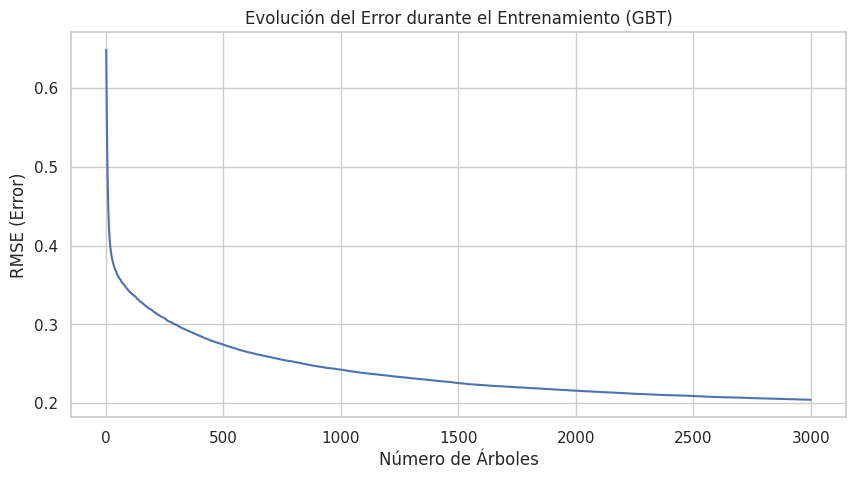

In [59]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(10, 5))
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel("Número de Árboles")
plt.ylabel("RMSE (Error)")
plt.title("Evolución del Error durante el Entrenamiento (GBT)")
plt.grid(True)
plt.show()

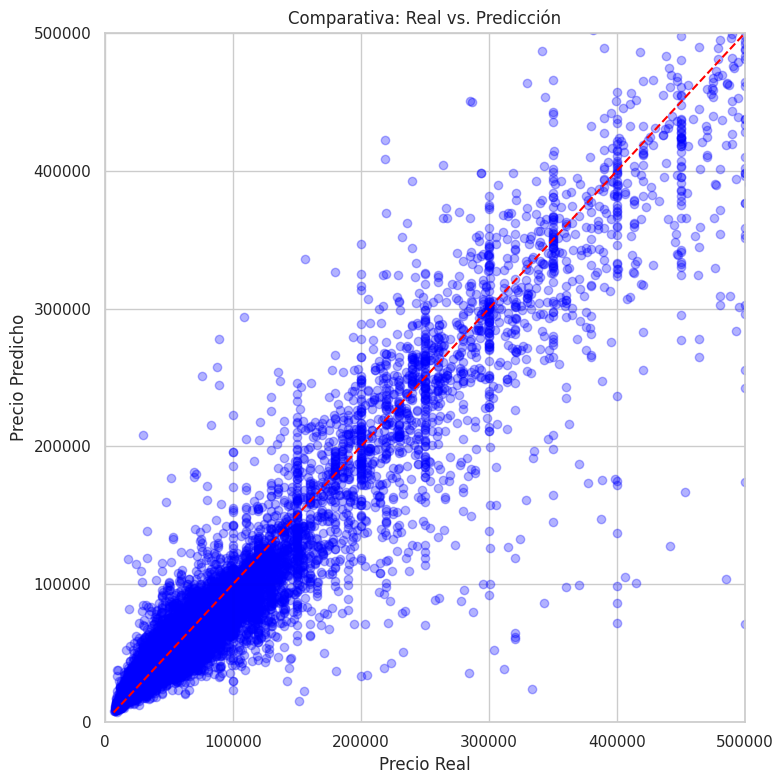

In [60]:
all_labels = []
all_preds = []

for features, labels in test_df:
    preds = model.predict(features, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds.flatten())

real_labels = np.expm1(all_labels)
real_preds = np.expm1(all_preds)

plt.figure(figsize=(8, 8))
plt.scatter(real_labels, real_preds, alpha=0.3, color='blue')
plt.plot([min(real_labels), max(real_labels)], [min(real_labels), max(real_labels)], color='red', linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Comparativa: Real vs. Predicción")

plt.xlim(0, 500000) 
plt.ylim(0, 500000)

plt.tight_layout()
plt.show()

/tmp/ipykernel_172593/1909013796.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')


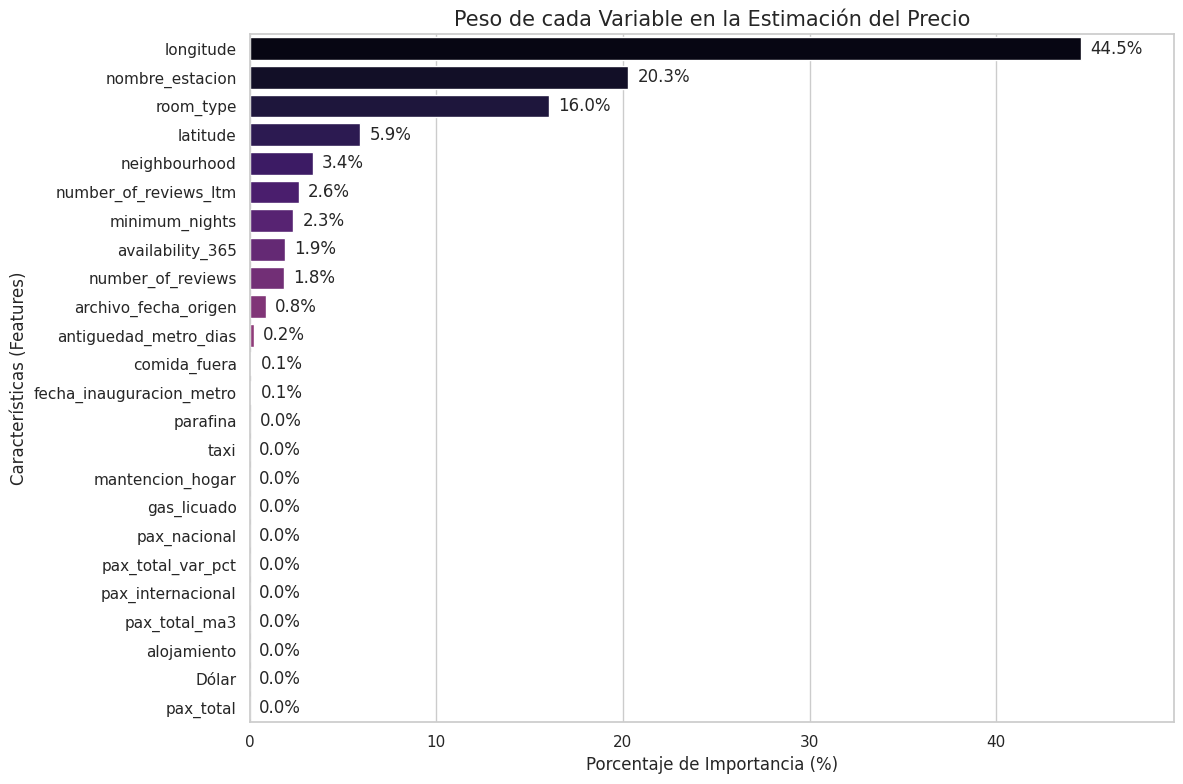

In [43]:
inspector = model.make_inspector()

# Utiliza la funcion variable_importance para ver que tanto aporto cada variable.
# Se utiliza SUM_SCORE para ver el score de cada variable
importances = inspector.variable_importances()["SUM_SCORE"] # Retorna un diccionario

feature_names = [i[0].name for i in importances] # Convertir el diccionario en una lista
feature_values = [i[1] for i in importances]

df_imp = pd.DataFrame({'Variable': feature_names, 'Valor': feature_values}) # Se transforma la lista en un Dataframe con columna variable y valor, las filas corresponderian a la importancia de las variables

# 4. Convertir a porcentaje (%)
df_imp['Porcentaje'] = (df_imp['Valor'] / df_imp['Valor'].sum()) * 100
df_imp = df_imp.sort_values(by='Porcentaje', ascending=False)


# Crear el gráfico
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')

# Añadir etiquetas de porcentaje al final de cada barra
for p in ax.patches: # patches es la barra de cada grafico
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 0.5, p.get_y() + p.get_height()/2), 
                va='center')

plt.title("Peso de cada Variable en la Estimación del Precio", fontsize=15)
plt.xlabel("Porcentaje de Importancia (%)")
plt.ylabel("Características (Features)")
plt.xlim(0, df_imp['Porcentaje'].max() + 5) # Espacio para el texto
plt.tight_layout()
plt.show()

## Random Forest Regressor
https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/RandomForestModel

In [40]:
model_rf = tfdf.keras.RandomForestModel(
    task = tfdf.keras.Task.REGRESSION,
    num_trees = 500, 
    max_depth = 16, 
    growing_strategy = "BEST_FIRST_GLOBAL",
)
  
model_rf.fit(train_df) 

Use /tmp/tmp0o18byxt as temporary training directory
Reading training dataset...


Training dataset read in 0:00:01.155237. Found 139083 examples.
Training model...
Model trained in 0:00:09.698420
Compiling model...
Model compiled.


[INFO 26-05-14 01:12:37.1671 -04 kernel.cc:1233] Loading model from path /tmp/tmp0o18byxt/model/ with prefix a4c15e44e8f94a8d
[INFO 26-05-14 01:12:37.2023 -04 decision_forest.cc:660] Model loaded with 500 root(s), 30500 node(s), and 17 input feature(s).
[INFO 26-05-14 01:12:37.2023 -04 abstract_model.cc:1344] Engine "RandomForestGeneric" built
[INFO 26-05-14 01:12:37.2024 -04 kernel.cc:1061] Use fast generic engine


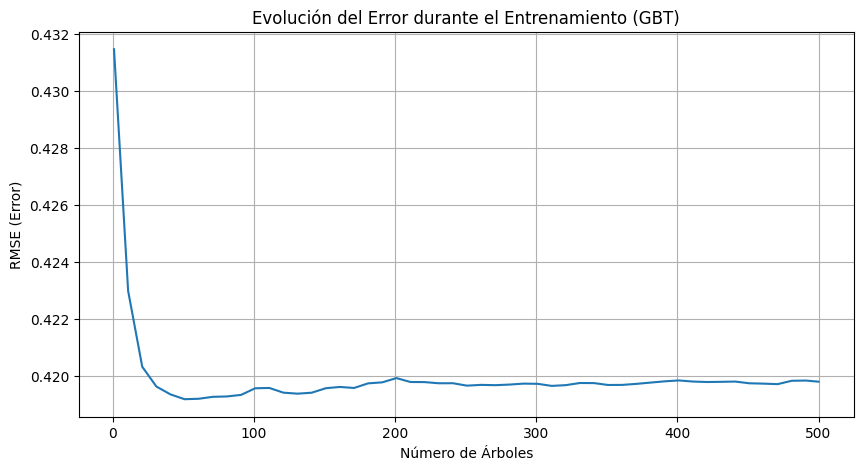

In [41]:
logs = model_rf.make_inspector().training_logs()

plt.figure(figsize=(10, 5))
plt.plot([log.num_trees for log in logs], [log.evaluation.rmse for log in logs])
plt.xlabel("Número de Árboles")
plt.ylabel("RMSE (Error)")
plt.title("Evolución del Error durante el Entrenamiento (GBT)")
plt.grid(True)
plt.show()

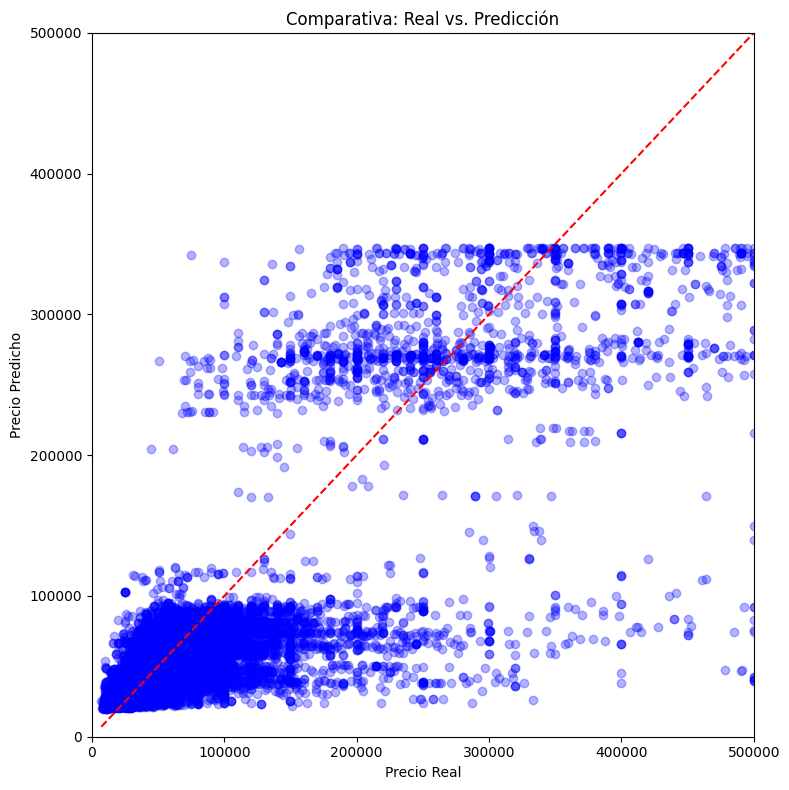

In [42]:
all_labels = []
all_preds = []

for features, labels in test_df:
    preds = model_rf.predict(features, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds.flatten())
    
real_labels = np.expm1(all_labels)
real_preds = np.expm1(all_preds)

# Graficar
plt.figure(figsize=(8, 8))
plt.scatter(real_labels, real_preds, alpha=0.3, color='blue')
plt.plot([min(real_labels), max(real_labels)], [min(real_labels), max(real_labels)], color='red', linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Comparativa: Real vs. Predicción")

# Limitar los ejes si tienes esos outliers de 100 millones
plt.xlim(0, 500000) 
plt.ylim(0, 500000)

plt.tight_layout()
plt.show()

/tmp/ipykernel_172593/4242983671.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')


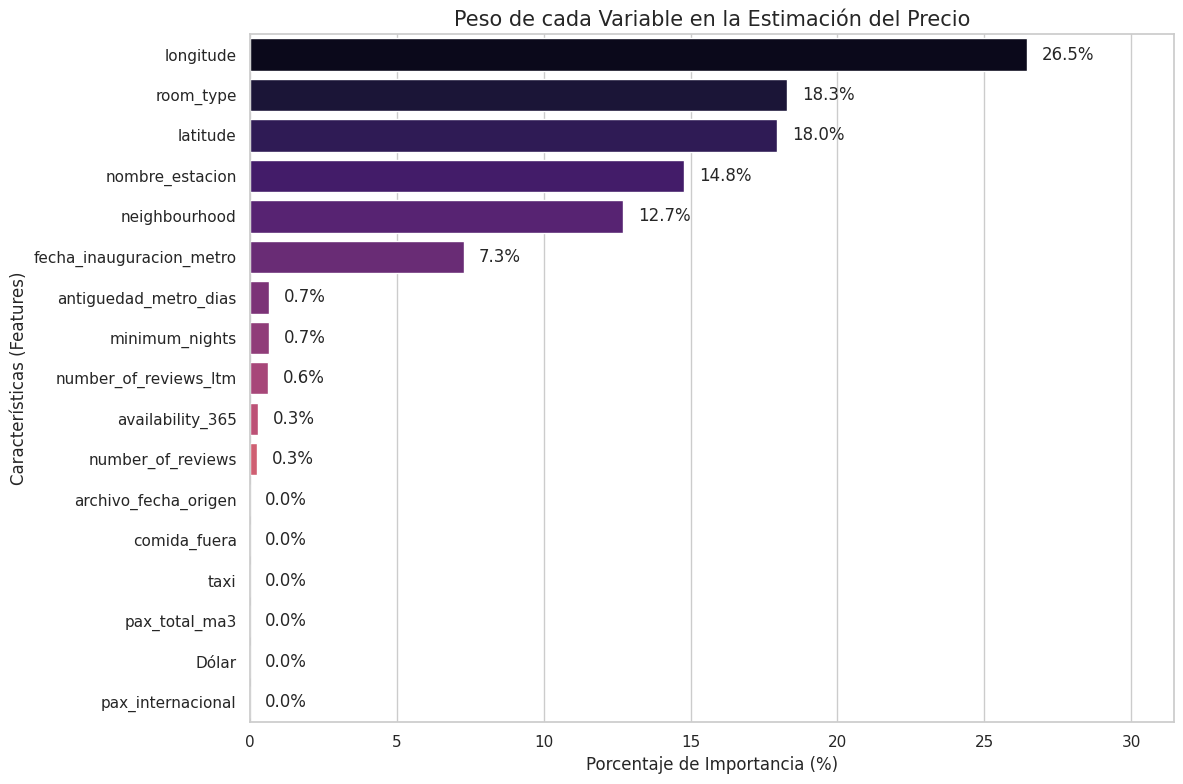

In [44]:
# 1. Obtener el inspector del modelo
inspector = model_rf.make_inspector()

# 2. Extraer la importancia (usualmente usamos 'SUM_SCORE' o 'MEAN_DECREASE_IN_ACCURACY')
# SUM_SCORE indica cuánto contribuyó cada variable a reducir la varianza del precio
importances = inspector.variable_importances()["SUM_SCORE"]

# 3. Convertir a un DataFrame de Pandas para manejar porcentajes
feature_names = [i[0].name for i in importances]
feature_values = [i[1] for i in importances]

df_imp = pd.DataFrame({'Variable': feature_names, 'Valor': feature_values})

# 4. Convertir a porcentaje (%)
df_imp['Porcentaje'] = (df_imp['Valor'] / df_imp['Valor'].sum()) * 100
df_imp = df_imp.sort_values(by='Porcentaje', ascending=False)


plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Crear el gráfico
ax = sns.barplot(x='Porcentaje', y='Variable', data=df_imp, palette='magma')

# Añadir etiquetas de porcentaje al final de cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width() + 0.5, p.get_y() + p.get_height()/2), 
                va='center')

plt.title("Peso de cada Variable en la Estimación del Precio", fontsize=15)
plt.xlabel("Porcentaje de Importancia (%)")
plt.ylabel("Características (Features)")
plt.xlim(0, df_imp['Porcentaje'].max() + 5) # Espacio para el texto
plt.tight_layout()
plt.show()

## Deep Neural Network

In [25]:
columnas_categoricas = ['neighbourhood', 'room_type', 'nombre_estacion']

df_procesado = pd.get_dummies(df, columns=columnas_categoricas)

In [26]:
df_procesado['archivo_fecha_origen'] = pd.to_datetime(df_procesado['archivo_fecha_origen'])
df_procesado['fecha_inauguracion_metro'] = pd.to_datetime(df_procesado['fecha_inauguracion_metro'])

# 2. Creamos nuevas columnas numéricas para el modelo
# Extraemos el año
df_procesado['archivo_fecha_origen_year'] = df_procesado['archivo_fecha_origen'].dt.year
df_procesado['fecha_inauguracion_metro_year'] = df_procesado['fecha_inauguracion_metro'].dt.year

# Extraemos el mes (muy útil para capturar temporadas altas en Airbnb)
df_procesado['archivo_fecha_origen_month'] = df_procesado['archivo_fecha_origen'].dt.month
df_procesado['fecha_inauguracion_metro_month'] = df_procesado['fecha_inauguracion_metro'].dt.month

# 3. Eliminamos las columnas originales de texto/fecha
# Ya no las necesitamos porque el modelo no las puede procesar
df_procesado = df_procesado.drop(['archivo_fecha_origen', 'fecha_inauguracion_metro'], axis=1)

print("Transformación de fechas completada.")
print(df_procesado)

Transformación de fechas completada.
         latitude  longitude      price  minimum_nights  number_of_reviews  \
0      -33.437666 -70.646033  10.596660        0.693147           1.098612   
1      -33.469590 -70.626490   9.606294        1.386294           1.945910   
2      -33.454630 -70.659130  10.182255        1.386294           0.693147   
3      -33.451410 -70.643540   9.998843        1.386294           4.382027   
4      -33.395420 -70.548520  11.350418        2.079442           4.143135   
...           ...        ...        ...             ...                ...   
189686 -33.408490 -70.549390  11.672763        1.386294           2.197225   
189687 -33.458130 -70.669446  10.834844        1.098612           0.693147   
189688 -33.456201 -70.571530  10.809748        0.693147           2.397895   
189689 -33.437268 -70.645229  10.896758        0.693147           1.386294   
189690 -33.429590 -70.618800  10.764287        0.693147           3.828641   

        availability_365  

In [46]:
df_procesado = df_procesado.dropna()

In [27]:
df_procesado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 173854 entries, 0 to 189690
Columns: 173 entries, latitude to fecha_inauguracion_metro_month
dtypes: bool(149), float64(15), int32(4), int64(5)
memory usage: 59.2 MB


In [28]:
y = df_procesado['price']
x = df_procesado.drop(['price'], axis=1) # Se elimina la columna price y el resultado de eso se retorna a la variable x

# Separar los datos en train, validation, testing
x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.01, random_state=42) #This return a data frame type
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.01, random_state=42)

scaler = StandardScaler()  # Se crea la variables StandardScaler para estandarizar las variables

x_train_scaled = scaler.fit_transform(x_train) # Se utiliza la variable fit_transform para normalizar los datos de x_train
x_val_scaled = scaler.transform(x_val)

print(x_train_scaled)
# Crear Dataset para optimizar TF
# Se utilizara la funcion from_tensor_slices la cual transformara los datos en objetos tf.data.Dataset
# A su vez crea un flujo para que los datos se vayan agregando a la tarjeta de video uno a la vez.
train_ds = tf.data.Dataset.from_tensor_slices((x_train_scaled, y_train.values))
val_ds = tf.data.Dataset.from_tensor_slices((x_val_scaled, y_val.values))

# Optimizar Datasets
# Se utiliza shuffle para desordenar los datos en cada epoca
# batch agrupa los datos para que cada x cantidad de datos se cambien los pesos
# prefetch hace que mientras se estan entrenando datos, se este preparando el siguiente grupo
train_ds = train_ds.shuffle(buffer_size=10000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

[[-0.13083638 -0.25904596 -0.12148041 ... -1.07806184  0.10813694
  -0.56290419]
 [-1.34387897  0.05586254  3.03485104 ...  1.55351495  1.36146334
   1.75397257]
 [ 1.1079102   0.66829706 -0.74978501 ...  1.09298901  1.04813174
  -1.14212337]
 ...
 [-0.04133694 -0.15177467 -0.74978501 ... -0.88069358  0.42146854
   0.88514379]
 [-0.48109198 -0.48120825 -0.12148041 ... -1.07806184 -0.51852626
  -0.56290419]
 [-0.46444942 -0.41111402 -0.74978501 ... -1.07806184  1.04813174
  -0.56290419]]


In [29]:
input_columns = x_train.shape[1]
model_mlp = keras.Sequential(
    [
        layers.Dense(256, activation="relu", input_shape=(input_columns,), name="layer1"),
        layers.BatchNormalization(), # Esto normaliza los datos para que haya una media cercana a 0 y una desviacion estandar cercana a 1
        layers.Dense(128, activation="relu", name="layer2"),
        layers.Dense(64, name="layer3"),
        layers.Dense(1)
    ]
)
model_mlp.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 layer1 (Dense)              (None, 256)               44288     
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 layer2 (Dense)              (None, 128)               32896     
                                                                 
 layer3 (Dense)              (None, 64)                8256      
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 86529 (338.00 KB)
Trainable params: 86017 (336.00 KB)
Non-trainable params: 512 (2.00 KB)
__________________

In [44]:
print(input_columns)

178


In [30]:
model_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='mean_squared_error',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError()], # se utiliza mae para ver la diferencia real en precio a la que se esta
)

history = model_mlp.fit(
    train_ds,
    validation_data = val_ds,
    epochs=50,
    verbose = 1 # Para ver en terminal como va el entrenamiento
)

Epoch 1/50
5325/5325 [==============================] - 6s 969us/step - loss: 1.8204 - mae: 0.7499 - root_mean_squared_error: 1.3492 - val_loss: 1.5741 - val_mae: 0.6564 - val_root_mean_squared_error: 1.2546
Epoch 2/50
5325/5325 [==============================] - 6s 1ms/step - loss: 0.3203 - mae: 0.4264 - root_mean_squared_error: 0.5659 - val_loss: 1.0919 - val_mae: 0.5489 - val_root_mean_squared_error: 1.0449
Epoch 3/50
5325/5325 [==============================] - 6s 1ms/step - loss: 0.2557 - mae: 0.3765 - root_mean_squared_error: 0.5057 - val_loss: 0.7145 - val_mae: 0.4023 - val_root_mean_squared_error: 0.8453
Epoch 4/50
5325/5325 [==============================] - 6s 1ms/step - loss: 0.2254 - mae: 0.3505 - root_mean_squared_error: 0.4747 - val_loss: 0.5923 - val_mae: 0.3884 - val_root_mean_squared_error: 0.7696
Epoch 5/50
5325/5325 [==============================] - 6s 1ms/step - loss: 0.2086 - mae: 0.3348 - root_mean_squared_error: 0.4568 - val_loss: 0.4345 - val_mae: 0.3557 - val_

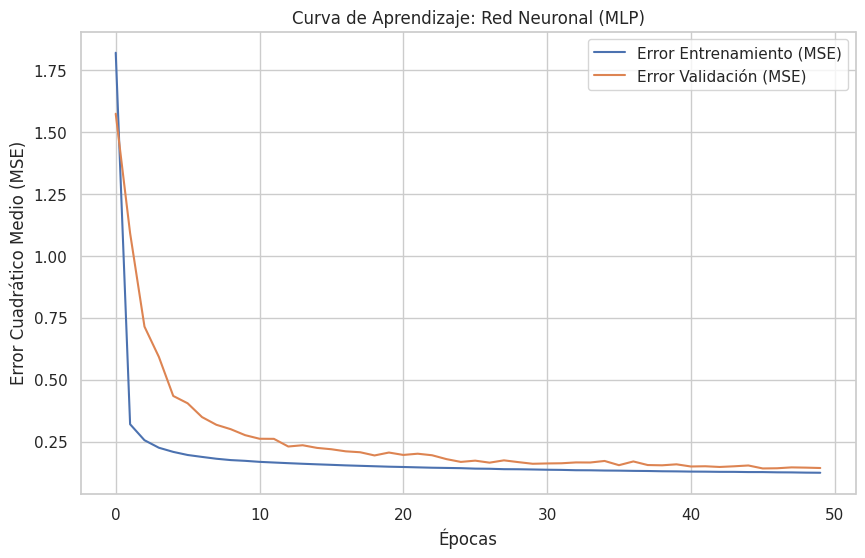

In [61]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(history.history['val_loss'], label='Error Validación (MSE)')
plt.title('Curva de Aprendizaje: Red Neuronal (MLP)')
plt.xlabel('Épocas')
plt.ylabel('Error Cuadrático Medio (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [62]:
x_test_scaled = scaler.transform(x_test)
test_ds = tf.data.Dataset.from_tensor_slices((x_test_scaled, y_test.values))
test_ds = test_ds.batch(32)

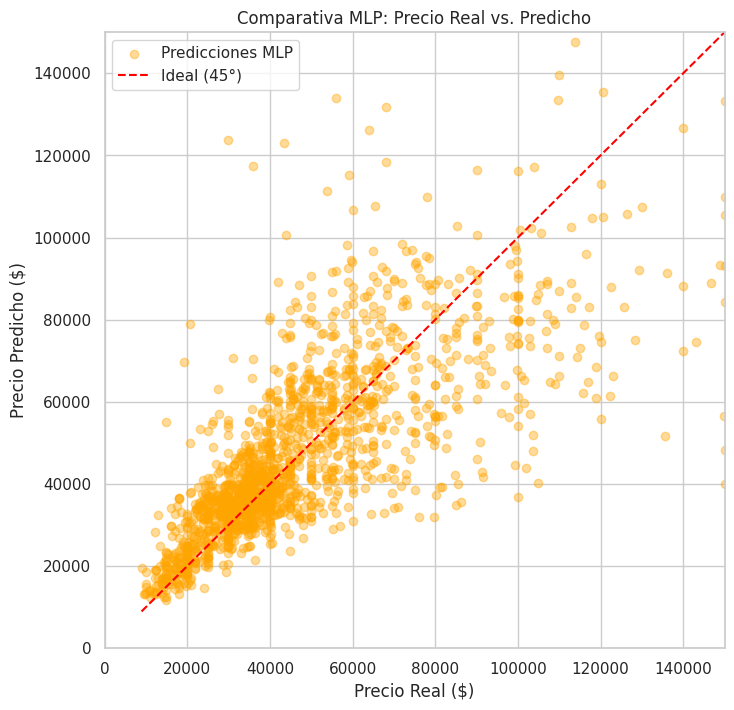

In [65]:
all_labels = []
all_preds = []

for features, labels in test_ds:
    preds = model_mlp.predict(features, verbose=0)
    all_labels.extend(labels.numpy())
    all_preds.extend(preds.flatten())
    
real_labels = np.expm1(all_labels)
real_preds = np.expm1(all_preds)

plt.figure(figsize=(8, 8))
plt.scatter(real_labels, real_preds, alpha=0.4, color='orange', label='Predicciones MLP')
plt.plot([min(real_labels), max(real_labels)], [min(real_labels), max(real_labels)], color='red', linestyle='--', label='Ideal (45°)')
plt.title('Comparativa MLP: Precio Real vs. Predicho')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.legend()
plt.xlim(0, 150000) # Ver solo hasta 300 mil pesos
plt.ylim(0, 150000)
plt.show()

Calculando importancia (esto probará cada una de las 179 variables)...


/tmp/ipykernel_172593/1005378929.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Categoria_Consolidada', data=df_final, palette='viridis')


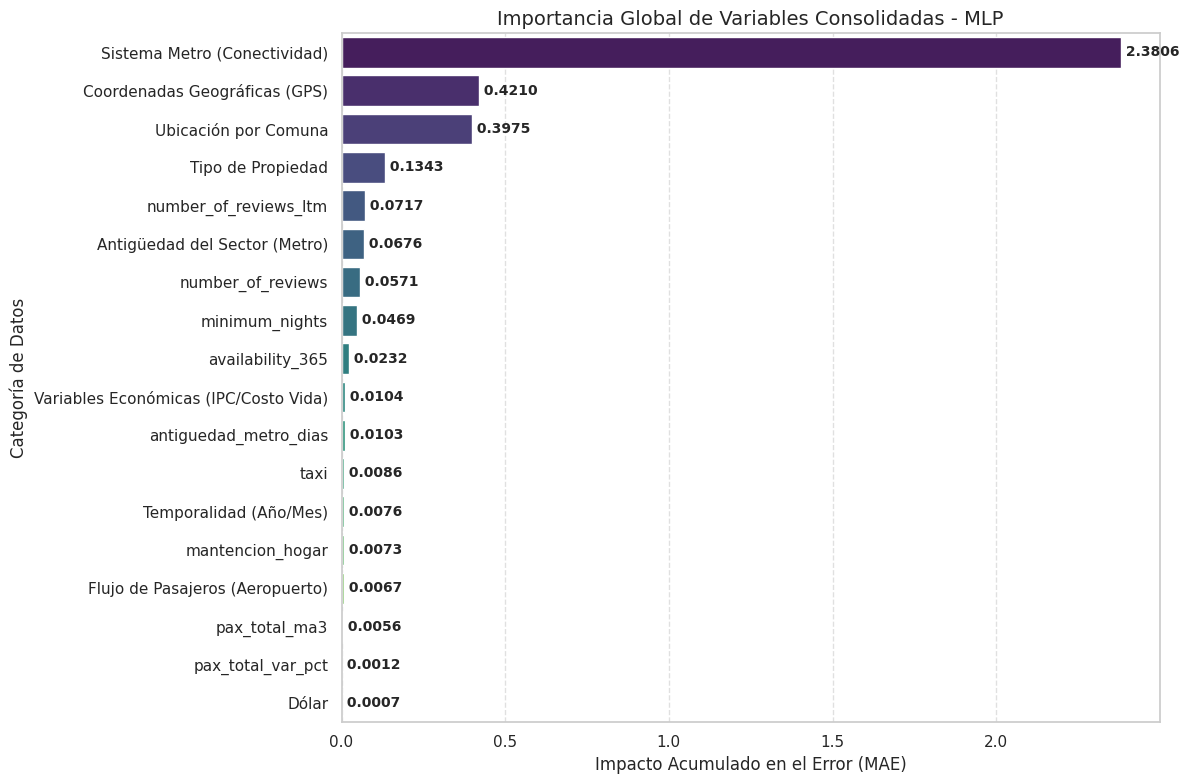

In [ ]:
X_sample = x_test_scaled[:5000]
y_sample = y_test.values[:5000]

baseline_preds = model_mlp.predict(X_sample, verbose=0)
baseline_mae = mean_absolute_error(y_sample, baseline_preds)

importances = []
feature_names = x_test.columns 

for i in range(X_sample.shape[1]):
    # Guardamos la columna original
    save_col = X_sample[:, i].copy()
    
    # Desordenamos la columna i
    np.random.shuffle(X_sample[:, i])
    
    # Medimos el nuevo error
    shuffled_preds = model_mlp.predict(X_sample, verbose=0)
    shuffled_mae = mean_absolute_error(y_sample, shuffled_preds)
    
    # La importancia es cuánto aumentó el error (en pesos o log-puntos)
    importances.append(shuffled_mae - baseline_mae)
    
    # Restauramos la columna original para la siguiente iteración
    X_sample[:, i] = save_col

# 2. Crear tabla y graficar
df_todas = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})

# 2. Definimos la función de mapeo para agrupar las 179 columnas
def mapear_categoria(nombre):
    if 'nombre_estacion_' in nombre:
        return 'Sistema Metro (Conectividad)'
    elif 'neighbourhood_' in nombre:
        return 'Ubicación por Comuna'
    elif 'room_type_' in nombre:
        return 'Tipo de Propiedad'
    elif 'archivo_fecha_origen_' in nombre:
        return 'Temporalidad (Año/Mes)'
    elif 'fecha_inauguracion_metro_' in nombre:
        return 'Antigüedad del Sector (Metro)'
    elif nombre in ['latitude', 'longitude']:
        return 'Coordenadas Geográficas (GPS)'
    elif nombre in ['pax_internacional', 'pax_nacional', 'pax_total']:
        return 'Flujo de Pasajeros (Aeropuerto)'
    elif nombre in ['alojamiento', 'comida_fuera', 'gas_licuado', 'parafina']:
        return 'Variables Económicas (IPC/Costo Vida)'
    else:
        # Para variables únicas como 'minimum_nights', 'Dólar', 'availability_365', etc.
        return nombre 

# 3. Aplicamos el agrupamiento a las 179 filas
df_todas['Categoria_Consolidada'] = df_todas['Variable'].apply(mapear_categoria)

# 4. Sumamos las importancias de cada grupo
# Esto es vital: suma el impacto de las 100+ estaciones en una sola métrica
df_final = df_todas.groupby('Categoria_Consolidada')['Importancia'].sum().reset_index()

# 5. Ordenamos de mayor a menor para que el gráfico sea legible
df_final = df_final.sort_values(by='Importancia', ascending=False)

# 6. Graficamos el 100% de tus datos agrupados
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Categoria_Consolidada', data=df_final, palette='viridis')

# Añadimos los valores exactos al final de cada barra para mayor precisión técnica
for i, val in enumerate(df_final['Importancia']):
    plt.text(val, i, f' {val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.title('Importancia Global de Variables Consolidadas - MLP', fontsize=14)
plt.xlabel('Impacto Acumulado en el Error (MAE)', fontsize=12)
plt.ylabel('Categoría de Datos', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()